# Specific Stock Simulation


In [10]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [11]:
ticker = "AIE.L"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "6mo"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [12]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [13]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [14]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,234.0,234.000000,225.000000,227.0,227.000000,990932,AIE.L,NaN,NaN,...,NaN,NaN,-7.0,0.05,-0.05,-0.15,0.0,-0.03625,-0.062963,HOLD
1,2026-03-13,228.5,229.000000,223.500000,225.5,225.500000,825448,AIE.L,NaN,NaN,...,-0.006608,-0.006608,-3.0,0.10,-0.45,-0.15,0.0,-0.03625,-0.178462,WEAK SELL
2,2026-03-12,230.5,238.500000,228.397995,228.5,228.500000,1879453,AIE.L,NaN,NaN,...,0.013304,0.006608,-2.0,0.40,-0.15,-0.15,0.0,-0.03625,0.019537,HOLD
3,2026-03-11,235.0,240.000000,232.000000,232.0,232.000000,423889,AIE.L,NaN,NaN,...,0.015317,0.022026,-3.0,0.35,-0.20,-0.15,0.0,-0.03625,-0.013463,HOLD
4,2026-03-10,236.0,239.500000,231.500000,235.5,235.500000,681466,AIE.L,NaN,NaN,...,0.015086,0.037445,-0.5,0.35,-0.20,-0.15,0.0,-0.03625,-0.013463,HOLD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,2025-09-22,270.0,274.000000,269.402008,271.5,271.494965,393959,AIE.L,262.00,267.250,...,0.014953,0.196035,1.5,0.05,-0.70,-0.15,0.0,-0.03625,-0.277463,STRONG SELL
123,2025-09-19,269.5,274.000000,269.500000,272.0,271.994934,708873,AIE.L,262.95,266.875,...,0.001842,0.198238,2.5,0.05,-0.70,-0.15,0.0,-0.03625,-0.277463,STRONG SELL
124,2025-09-18,270.0,272.000000,268.500000,270.5,270.494965,503616,AIE.L,263.95,266.450,...,-0.005515,0.191630,0.5,0.05,-0.70,-0.15,0.0,-0.03625,-0.277463,STRONG SELL
125,2025-09-17,270.0,272.000000,265.500000,272.0,271.994934,305066,AIE.L,265.45,266.300,...,0.005545,0.198238,2.0,0.05,-0.80,-0.15,0.0,-0.03625,-0.310462,STRONG SELL


In [15]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2026-02-02,BUY,WEAK BUY,241.0,0.020747,5.000000,95.000000,0.020747,99.989627
1,2026-03-13,SELL,WEAK SELL,227.0,0.001037,0.235477,95.235477,0.019710,99.679979


In [16]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2025-09-16,2026-03-16,100.0,95.235477,0.01971,241.0,227.0,4.474066,99.709544,-0.290456,-0.290456,1,1


## Block 6: Consolidated Chart


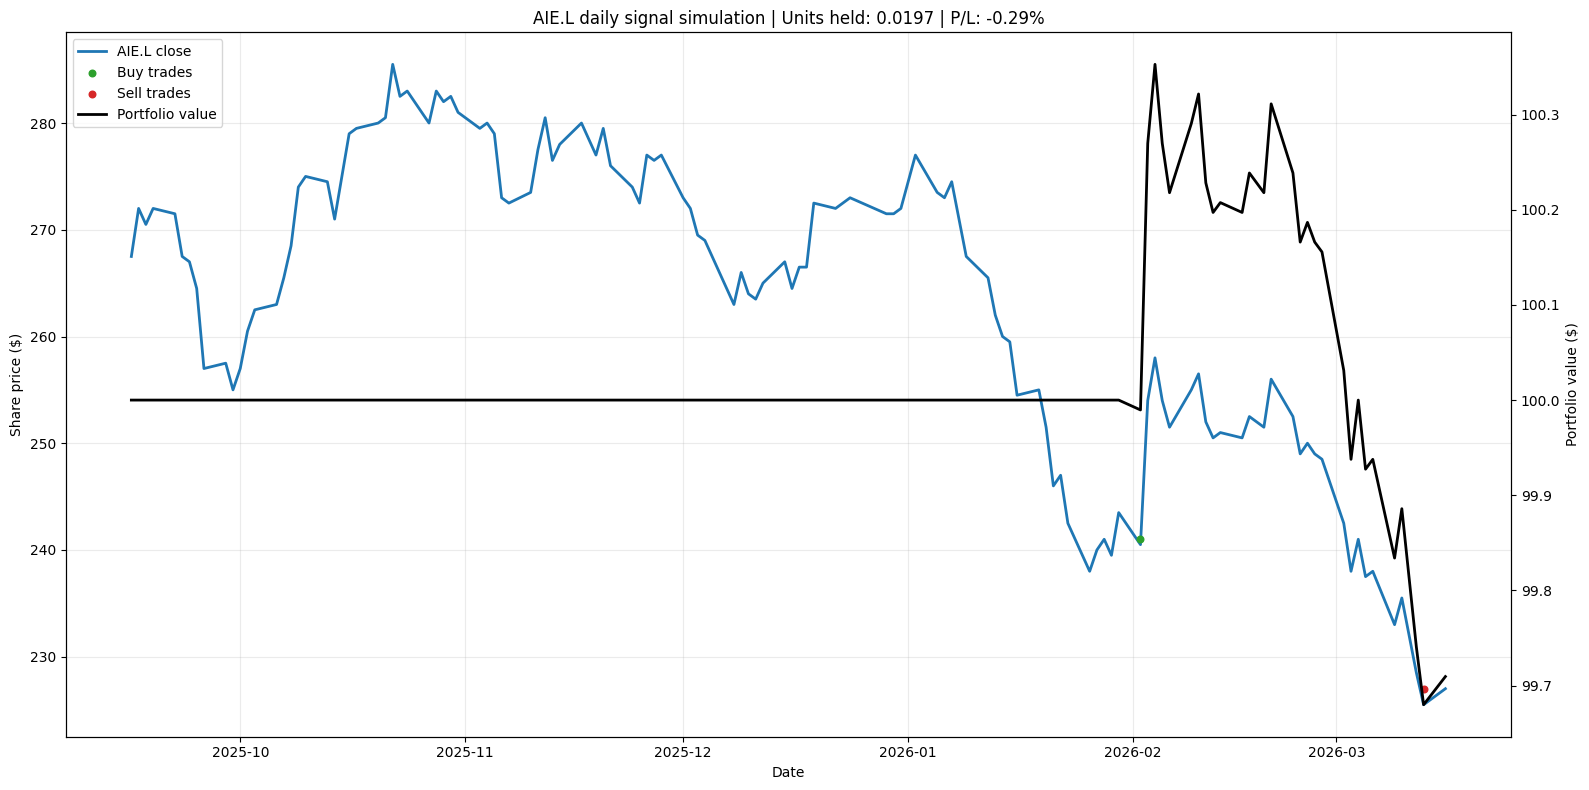

In [17]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [18]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2025-09-16,WEAK SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
1,2025-09-17,STRONG SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
2,2025-09-18,STRONG SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
3,2025-09-19,STRONG SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
4,2025-09-22,STRONG SELL,HOLD,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
122,2026-03-10,HOLD,HOLD,0.000000,0.000000,95.000000,0.020747,4.885892,99.885892,-0.114108
123,2026-03-11,HOLD,HOLD,0.000000,0.000000,95.000000,0.020747,4.813278,99.813278,-0.186722
124,2026-03-12,HOLD,HOLD,0.000000,0.000000,95.000000,0.020747,4.740664,99.740664,-0.259336
125,2026-03-13,WEAK SELL,SELL,0.001037,0.235477,95.235477,0.019710,4.444502,99.679979,-0.320021
